## PROJECT-1

## Bussiness case :
   *  Required to  best model to predict the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables.
   *   They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.
   *   To find and detail the Risk Analysis and insurance rating(Normalized losses).

## Problem Statement:

Goal of the project:

Task-1 :

Prepare a complete data analysis report on the given data.

Task 2 :

Create a predictive model by applying some data science techniques for the price of cars with the available independent variables. That should help the management to understand how exactly the prices vary with the independent variables. They cna accordingly manipulate the design of the cars, the business strategy etc. to meet certan price level

In [1]:
# Loading required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Dataset
df=pd.read_csv(r"auto_imports.csv")

In [3]:
df.head(10)

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
5,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
6,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
7,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
8,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430
9,0,192,bmw,gas,std,four,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16925


In [4]:
# Dataset missing column name so that rename columns.
column_names = ["symboling","normalized-losses", "make","fuel-type", "aspiration",
    "num-of-doors","body-style","drive-wheels", "engine-location", "wheel-base", 
    "length","width","height", "curb-weight", "engine-type", "num-of-cylinders",
    "engine-size", "fuel-system", "bore", "stroke", "compression-ratio",
    "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv("auto_imports.csv", names=column_names, na_values="?", skiprows=1)
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
1,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
2,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
3,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
4,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250
5,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710
6,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920
7,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875
8,2,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16430
9,0,192.0,bmw,gas,std,four,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16925


In [5]:
df.tail()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
195,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845
196,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045
197,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485
198,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470
199,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,19,25,22625


In [6]:
df.shape

(200, 26)

In [7]:
df.dtypes

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               200 non-null    object 
 3   fuel-type          200 non-null    object 
 4   aspiration         200 non-null    object 
 5   num-of-doors       198 non-null    object 
 6   body-style         200 non-null    object 
 7   drive-wheels       200 non-null    object 
 8   engine-location    200 non-null    object 
 9   wheel-base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb-weight        200 non-null    int64  
 14  engine-type        200 non-null    object 
 15  num-of-cylinders   200 non-null    object 
 16  engine-size        200 non

In [9]:
df.describe()  # Statistical analysis on numerical data (int64,float64)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,200.000000,164.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,196.000000,196.000000,200.000000,198.000000,198.000000,200.000000,200.000000,200.000000
mean,0.830000,122.000000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,3.330000,3.259847,10.170100,103.358586,5118.181818,25.200000,30.705000,13205.690000
std,1.248557,35.442168,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,0.271303,0.317383,4.014163,37.645120,481.666657,6.432487,6.827227,7966.982558
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,3.150000,3.110000,8.575000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10270.000000
75%,2.000000,150.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.750000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


 We can observe some variation and relationship within the features:
 * The minimum value for price is 5118 and maximum is 45400 and middle price (50%) is 10270 and has a std is high with predicting price of 7996, so we can expect there should be an outliers.
 * curb_weight has a high std of 518. We can expect outliers.
 * engine_size has a high std of 41.65. We can expect outlier in this also.
 All columns have different data range with variance. so Scaling is required.

In [10]:
df.describe(include='O') # statistical analysis of categorical data.

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
count,200,200,200,198,200,200,200,200,200,200
unique,22,2,2,2,5,3,2,6,7,8
top,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,32,180,164,113,94,118,197,145,156,91


# We can observe from above analysis
 * Toyota has more occuring frequent model.
 * The Dominant fuel usage in all types of vehicle is 'Gas' with recurrence of 180.
 * Most fuel system used is 'MPFI' and most cars having engine with '4 cylinders'.
 * 'standard' fuel aspiration is more and 'sedan' is dominating with most body styles

   These are important attributes/feature play vital role in predicting target price and this features shows how strongly co-related with target variable. 

In [11]:
# check for missing values
df.isnull().sum()

symboling             0
normalized-losses    36
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

We can find there are missing values in normalized losses, bore, stroke, horse power, no of doors and peak rpm. we need to handle them.

## Exploratory Data Analysis

In [12]:
# storing all numerical columns (int & float) into variable
num_data = df.select_dtypes(include=['int64','float64'])
# storing all categorical columns into variable
cat_data = df.select_dtypes(include='O')

## Univariate analysis

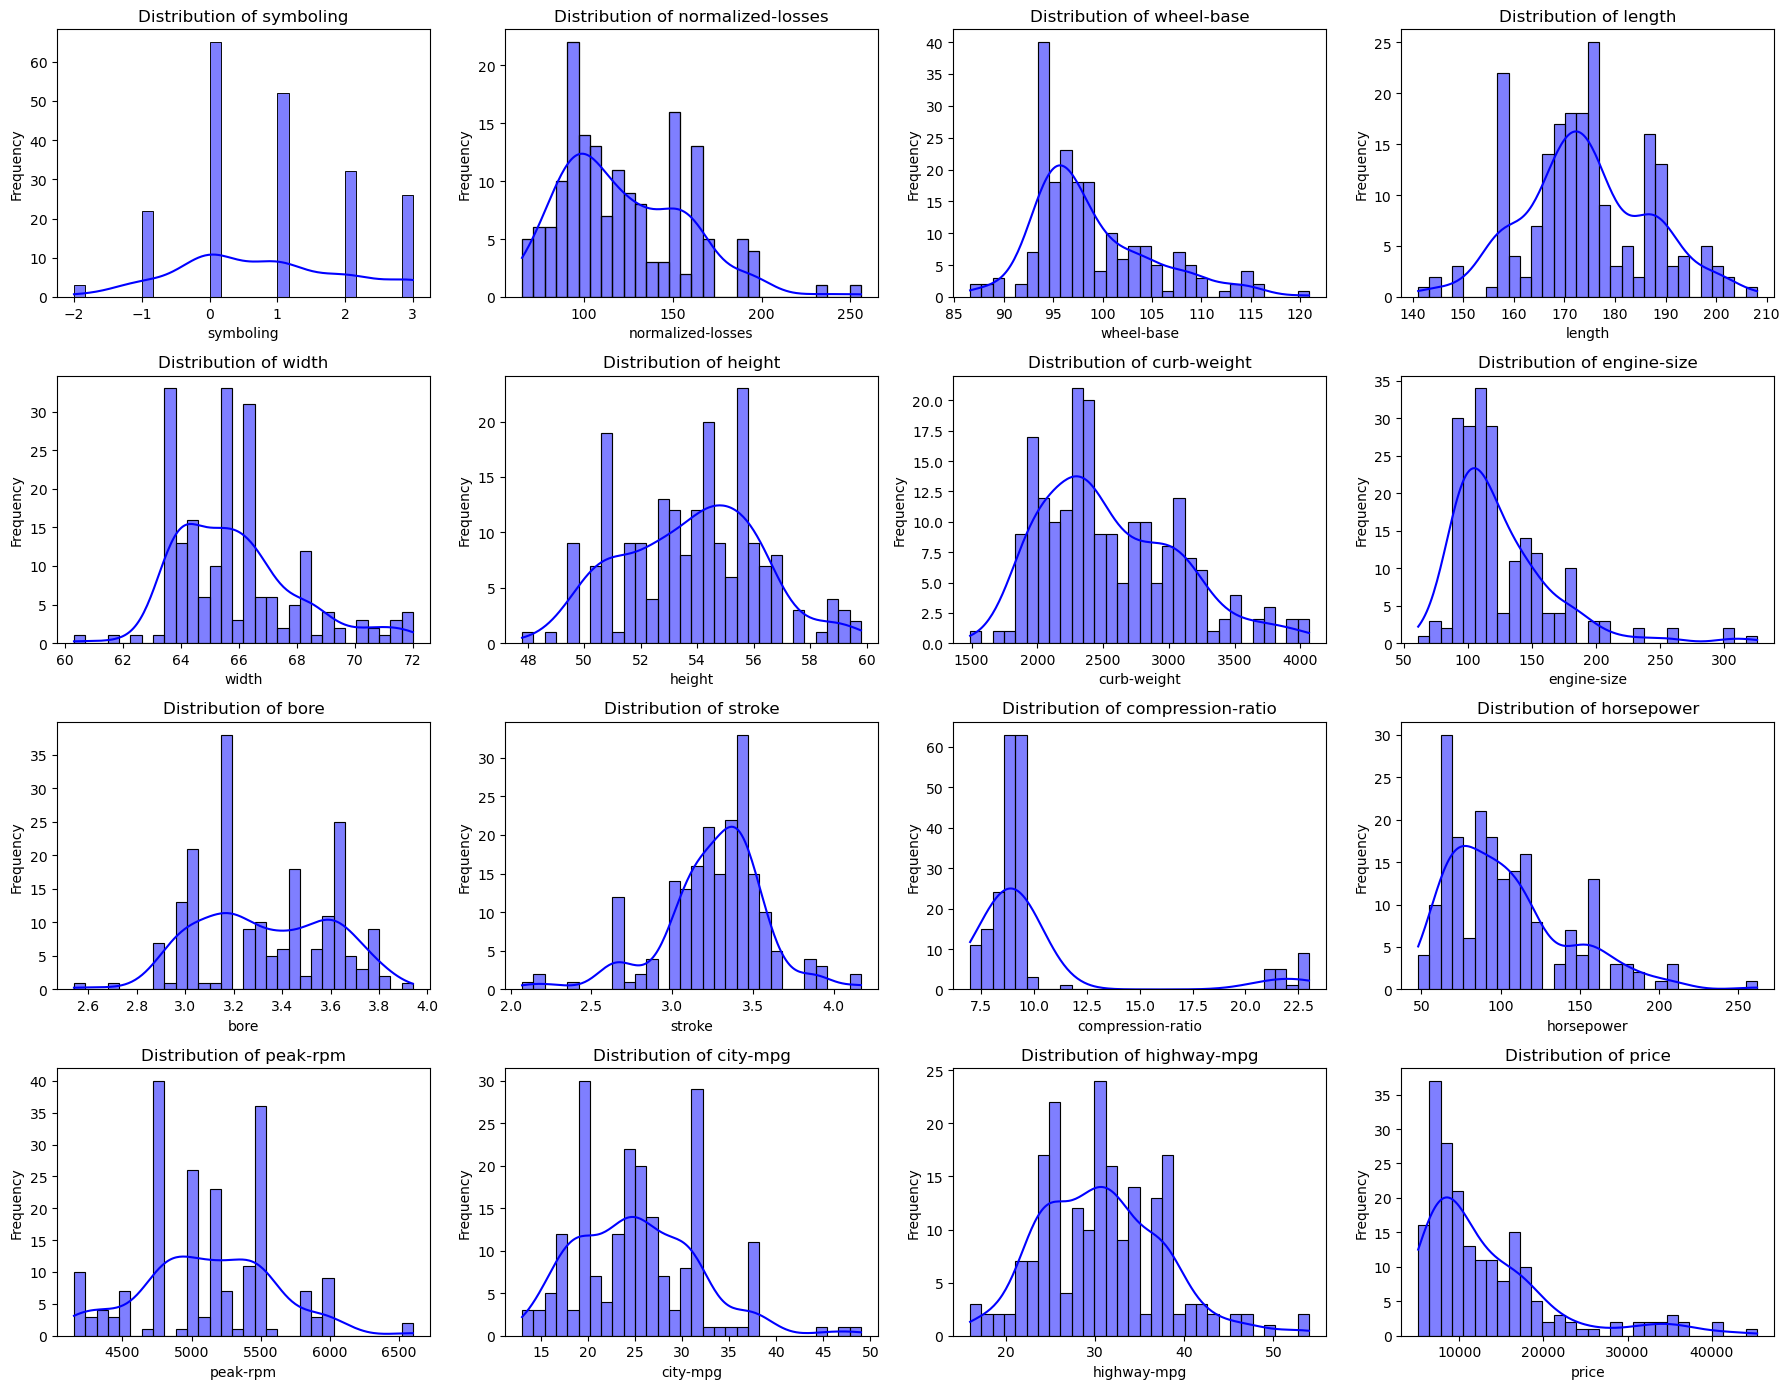

In [13]:
# plot the histogram curve for numerical_data to understand how data is distributed.

plt.figure(figsize=(18, 14))

for i, col in enumerate(num_data, 1):
    plt.subplot(4, 4, i)       # 4 rows, 4 columns
    sns.histplot(df[col], kde=True, bins=30, color='blue' )
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

plt.show()


## Symboling (Insurance Risk rating)
   The dataset column of symboling starts at -2 instead of -3 shows that lowest-risk cars or vehicles must be missing. Most cars fall within the range of 0 t0 1 range, explains dataset consists of mainly moderately risk vehicles and less high risk vehicles.

## Normalized Losses (Average Loss Payment per Insured vehicle per year)
   Most cars have normalized losses between range of 65 and 150, which indicates a concentration in mid-risk category. It would be helpful to check higher risk vehicles (higher losses) correspond to make and its features.

## Wheel Base
   Most cars with the wheel base ranging from 90 to 105 and above 110 wheelbase vehicles must be longer and have a much sufficient space inside and this may be increased length of the car and bigger in size may cause effect to increase in prize of car. The increased length, width and height of the car shows that it belong to SUV model and SUV are tends to much costlier.

## Curb Weight Distribution(1500-4000 lbs)
   The most cars dominate in between 1800-3300 lbs and again less weight cars may had increased performance, higher mileage and less safety and contrastly higher weight cars might be associated with less performace, mileage and more safety somewhat mileage and performance also depend on the factor of Aero-dynamics. This Distribution also suggest that dataset includes compact cars and heavier sedans/SUVs. Clustering within this range could help us to categorize vehicles into different weight classes.

## HorsePower (50 to 150 hp for most cars)
   Most cars are in the lower-to-mid horsepower range, likely indicating economy and mid-range vehicles. If outlier exists(eg: Sports car with much higher HP), they could impact model prediction.

## Peak RPM (4500-5500 for most cars)
   This RPM range typical for natural aspirated engine; Turbocharged engines may have different distribution with higher rpm rate. Checking its correlation with horsepower could reveal performance trends. 
   
## Price Distribution (5000 to 45000 USD )
   The concentration of vehicles in the price range of (5000-20000 USD) indicates that dataset most focused on economy and budget based mid-range cars. By Analyzing above range may helpful to identify outliers which contain luxury or premium cars.

## Engine Size (60 to 190 cubic inches/cc)
   The dataset includes a range from small compact engines to larger, more powerful ones. Comparing engine size with price and horsepower could help to understand the performancr vs cost trade-offs.


## Countplot for categorical columns

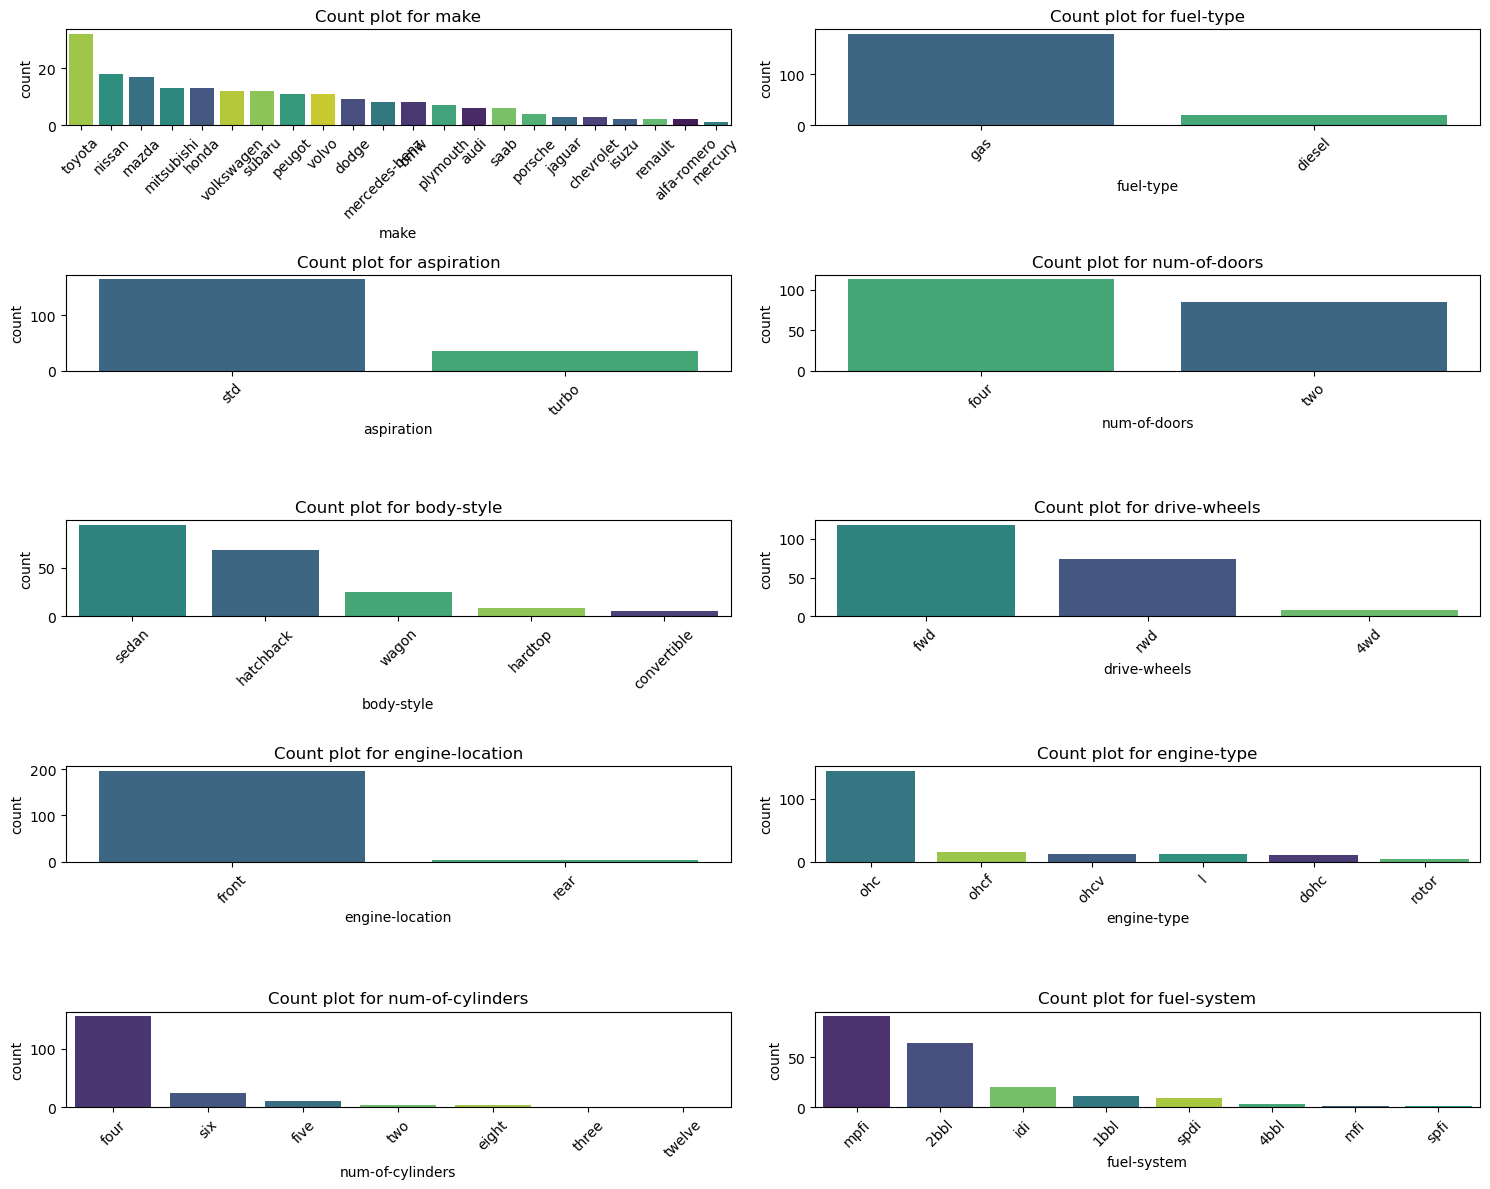

In [14]:
# plot the countplot for categorical_data to understand how data is distributed.

plt.figure(figsize=(15,12))

for i, col in enumerate(cat_data,1):
    plt.subplot(5,2,i)
    sns.countplot(data=df, x=df[col], hue=col, legend=False, palette="viridis",order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count plot for {col}')
    
plt.tight_layout()
plt.show()

## 1.Car Manufacturer Distribution
In the world most car make producer is Toyota but in dataset also it proves that most make model is Toyota and Nissan holds the second place and least is alfa-romero and mercury makes.

## 2.Drive Wheels Distribution
The majority of vehicles are FWD - Front-Wheel Drive, followed by RWD - Rare-Wheel Drive. 4WD - four wheel drives are least common.

## 3.Fuel-type Preference
Gasoline is the most preferred fuel type for most of vehicles. Desiel vehicles are less common.

## 4.Engine aspiration type
The most vehicles engines are of standard (naturally aspirated) and Turbo aspirations are less due to its higher cost involved with higher technology in make and performance.

## 5.Engine Type Distribution
More than 70% of vehicles have an OHV(Overhead Camshaft) engine. OHV engines are preferred due to their balance between effeciency and cost.

## 6.Body style preferences
Sedan is the most produced vehicle body style, making up approximately 48% of the cars followed by hatchback accounting for 32% of vehicles.

## 7.Number of Doors
Approximately 55% of the cars have four doors, making it most common choice. The remaining vehicles have two door configuration and 2 door cars may be premium, compact and open-roof cars.

## 8. Fuel System Type
More than 45% of cars in the dataset have MPFI(Multi-point fuel Injection) fuel system and these MPFI are enhancing combustion effeciency, performance and  best fuel economy.

## 9. Number of cylinders in the engine.
More than 70% cars are four cylinder engines and they are best in fuel effecient and performance and easier and less maintenance cost.



## Bivariate Analysis

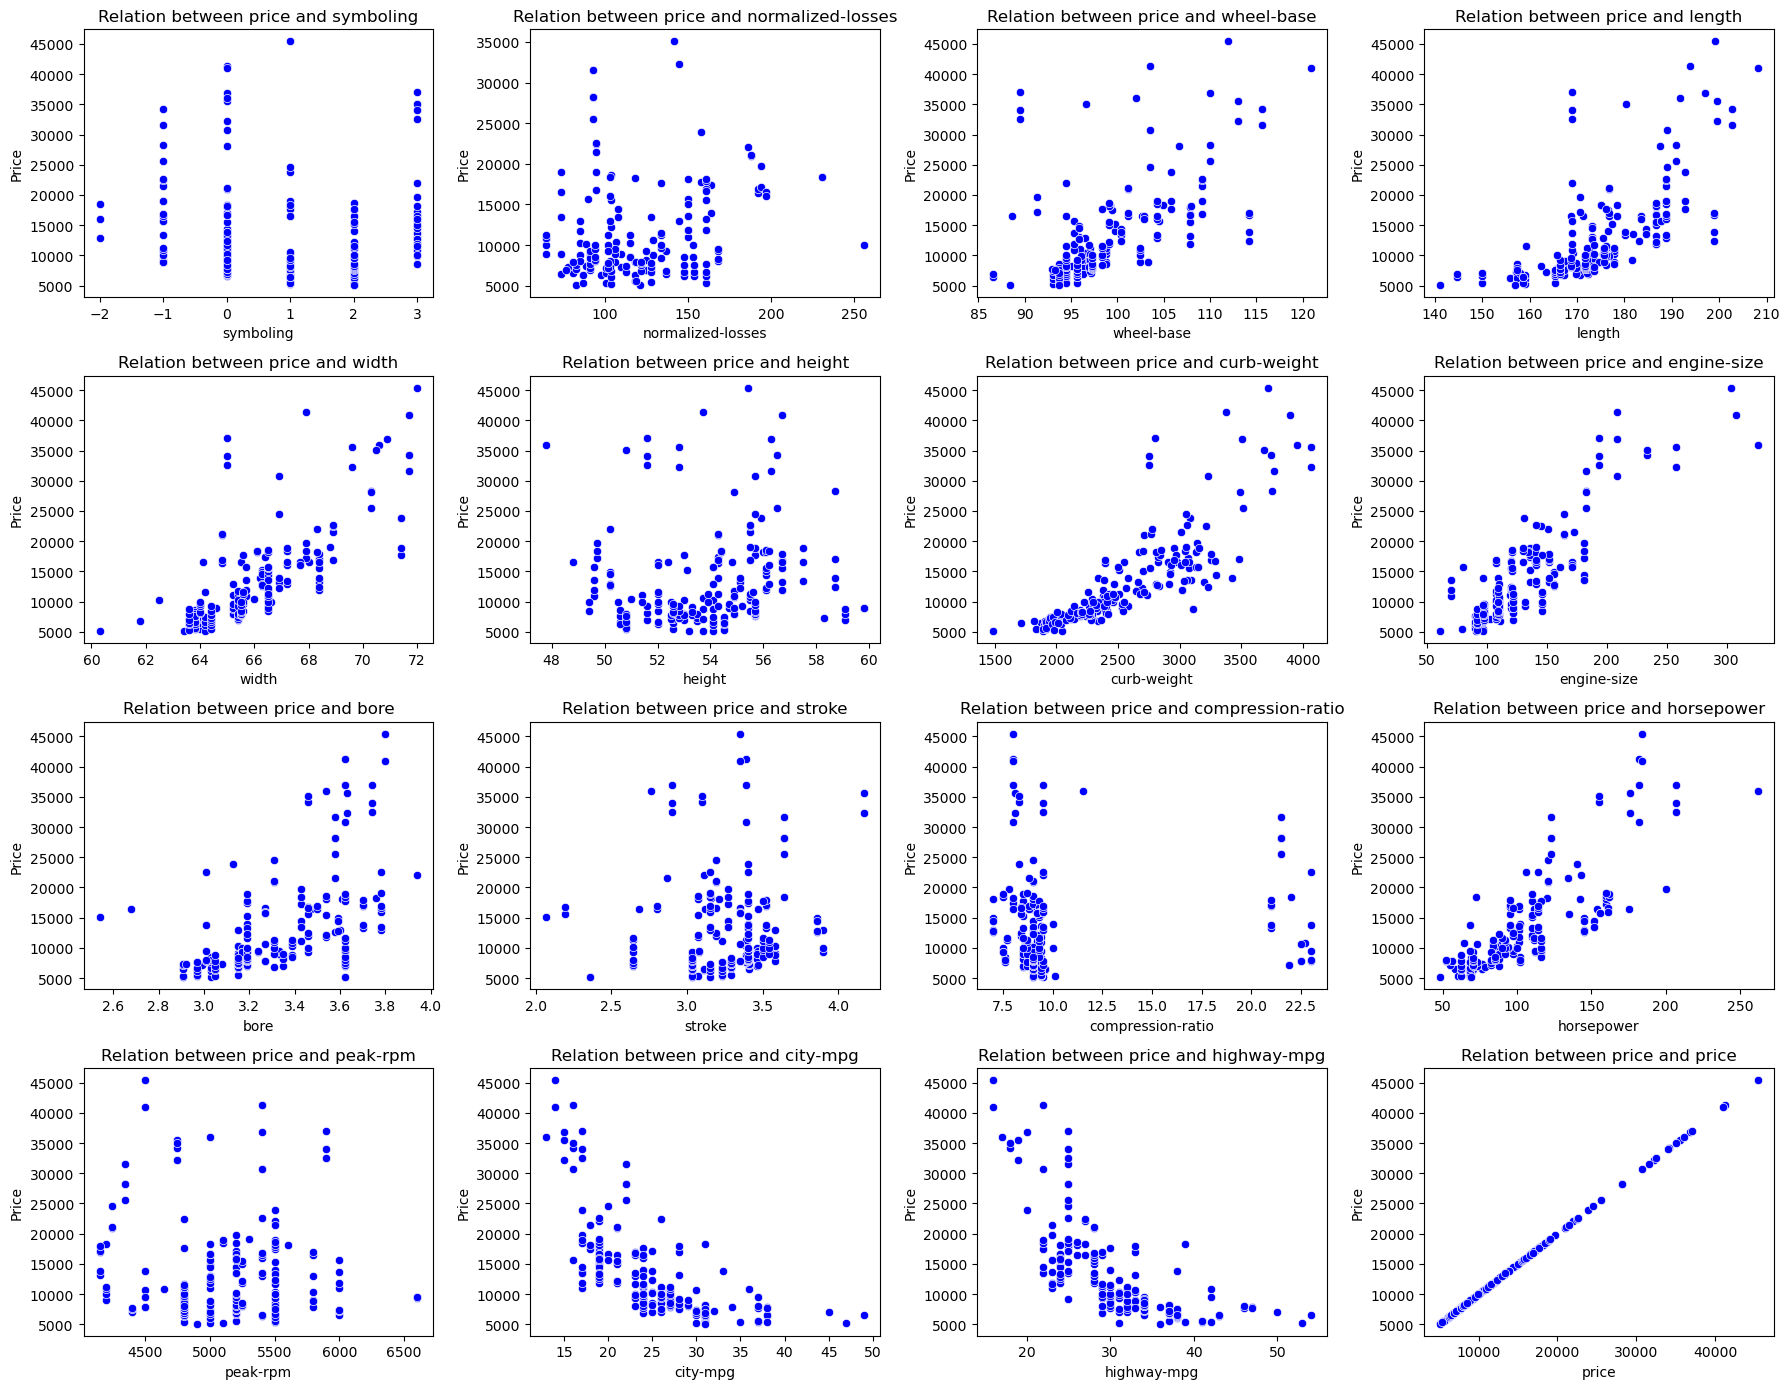

In [15]:
# plot the scatter plot  for numerical_data to understand how data is related with target.

plt.figure(figsize=(18, 14))

for i, column in enumerate(num_data, 1):
    plt.subplot(4, 4, i)       # 4 rows, 4 columns
    sns.scatterplot(data=num_data, x=df[column], y=df.price, color='blue' )
    plt.xlabel(column)
    plt.ylabel("Price")
    plt.title(f"Relation between price and {column}")
    plt.tight_layout()

plt.show()


* Length, Width & Curb Weight : Larger and heavier vehicles are more likely to be SUV often requires higher engine capacity to produce peak power and to pull heavier weights. a Require more materials, advanced engineering in material designs causes the higher production costs leads to higher prices.

* Engine size & Horsepower : A Bigger engine with more cylinders and higher horse power typically results in better performance which leads to increase in vehicle prize due to higher manufacturing costs, best materials to be used for overall comfort and for better handling of vehicles and to enhanced driving experience.

* City-mpg & Highway-mpg : Fuel effeciency is better in compact, smaller engine size, less performance vehicles and light vehicles are generally priced lower. Heavier, High-performance and luxury cars tend to have a Lower mpg due to big engine size, more horsepower and additional features that consume more fuel.

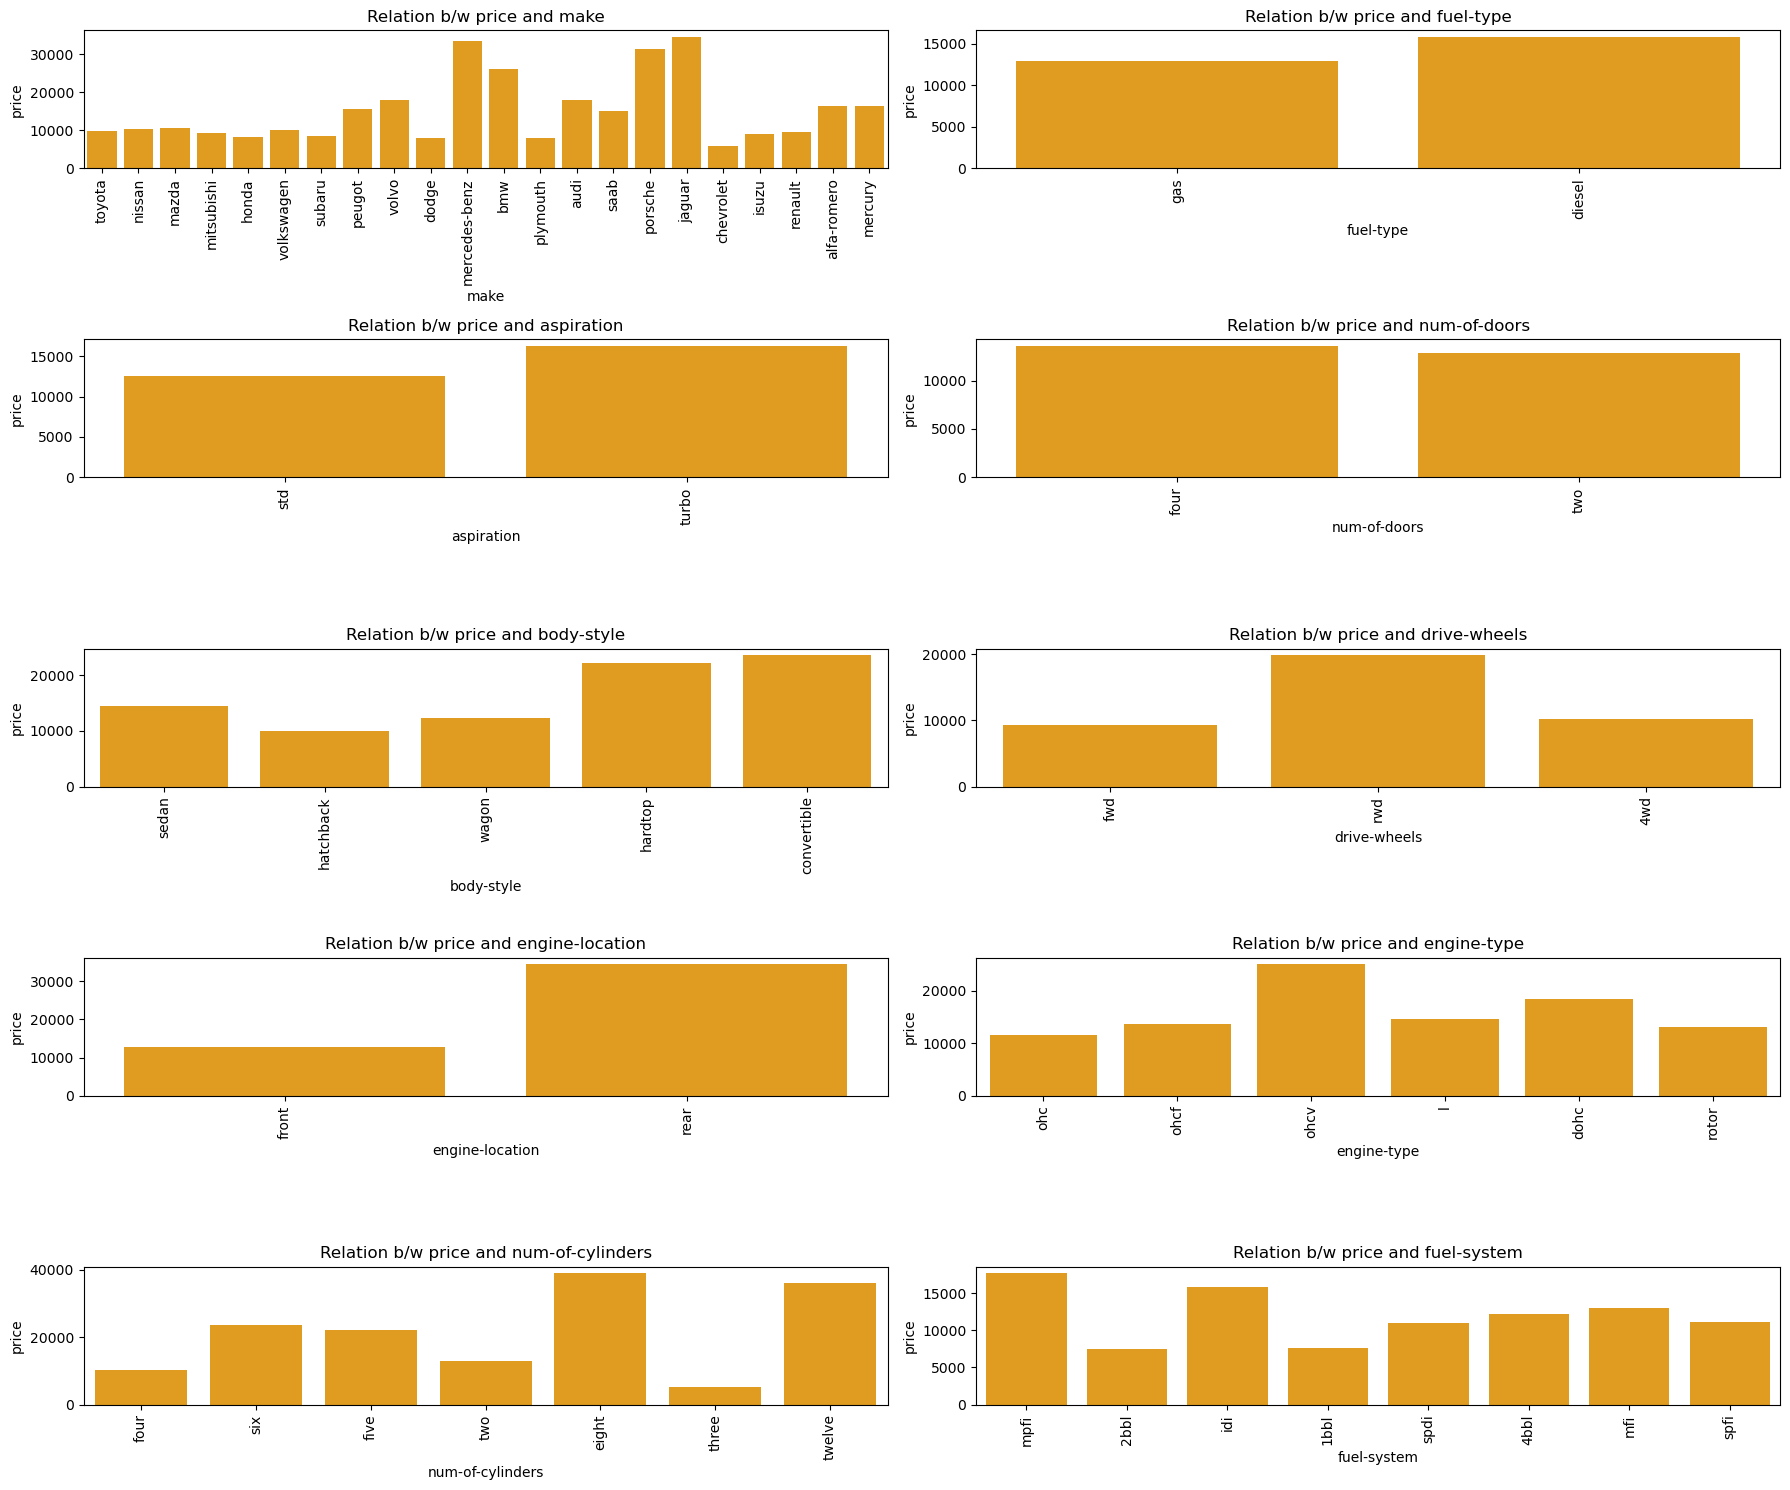

In [16]:
## plotting bar plots
plt.figure(figsize=(18,15))

for i, column in enumerate(cat_data,1):
    plt.subplot(5,2,i)
    sns.barplot(data=cat_data, x=df[column], y= df.price, color='orange', 
                order=df[column].value_counts().index, errorbar=None)
    plt.xticks(rotation=90)
    plt.title(f'Relation b/w price and {column}')
    plt.tight_layout()
plt.show()

* Mercedez Benz and BMW car brands are priced higher due to their luxury and premium. Porsche and Jaguar are mostly sports car and there produce luxury brand also and priced higher. Chevorlet brand priced at least.
* Vehicle equipped with Turbocharges priced higher due to advanced engineering and technology used in it to perform at higher rate.
* Rear-wheel-drive (RWD) vehicles generally have higher prices since they are commonly found in sports car and luxury models, offering better handling and superior power distribution.
* Diesel-powered vehicles are priced higher than gasoline engines due to their peak power and higher level of engineering technology used in manufacturing and they are fuel effecient and more durable also.
* Cars with 8-cylinders are normally found in high-end performance cars, making them significantly more expensive.

In [17]:
# To know which engine type of engine is more fuel effecient.
df.groupby('fuel-type').mean(['highway-mpg'])

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
fuel-type,,,,,,,,,,,,,,,,
diesel,0.100000,109.000000,104.390000,182.010000,67.430000,55.835000,2898.800000,135.700000,3.374500,3.485500,22.005000,84.450000,4435.00000,30.300000,34.750000,15838.150000
gas,0.911111,123.308725,98.232222,173.363333,65.727778,53.564444,2517.583333,125.877778,3.324943,3.234205,8.855111,105.483146,5194.94382,24.633333,30.255556,12913.194444


## Data Preprocessing and Data Cleaning

 Handling missing values

In [18]:
# for numeric data we can replace missing values with median because from above analysis we see that no columns are normally distributed.
num_column = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height',
           'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
           'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']
num_imputer = SimpleImputer(strategy='median')
df[num_column] = num_imputer.fit_transform(df[num_column])

In [19]:
# for categorical column missed value fills with the mode.
cat_column = ['num-of-doors', 'fuel-type', 'aspiration', 'body-style',
            'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_column] = cat_imputer.fit_transform(df[cat_column])

In [20]:
# check for missing values.
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [21]:
# check for duplicates
df.duplicated().sum()

0

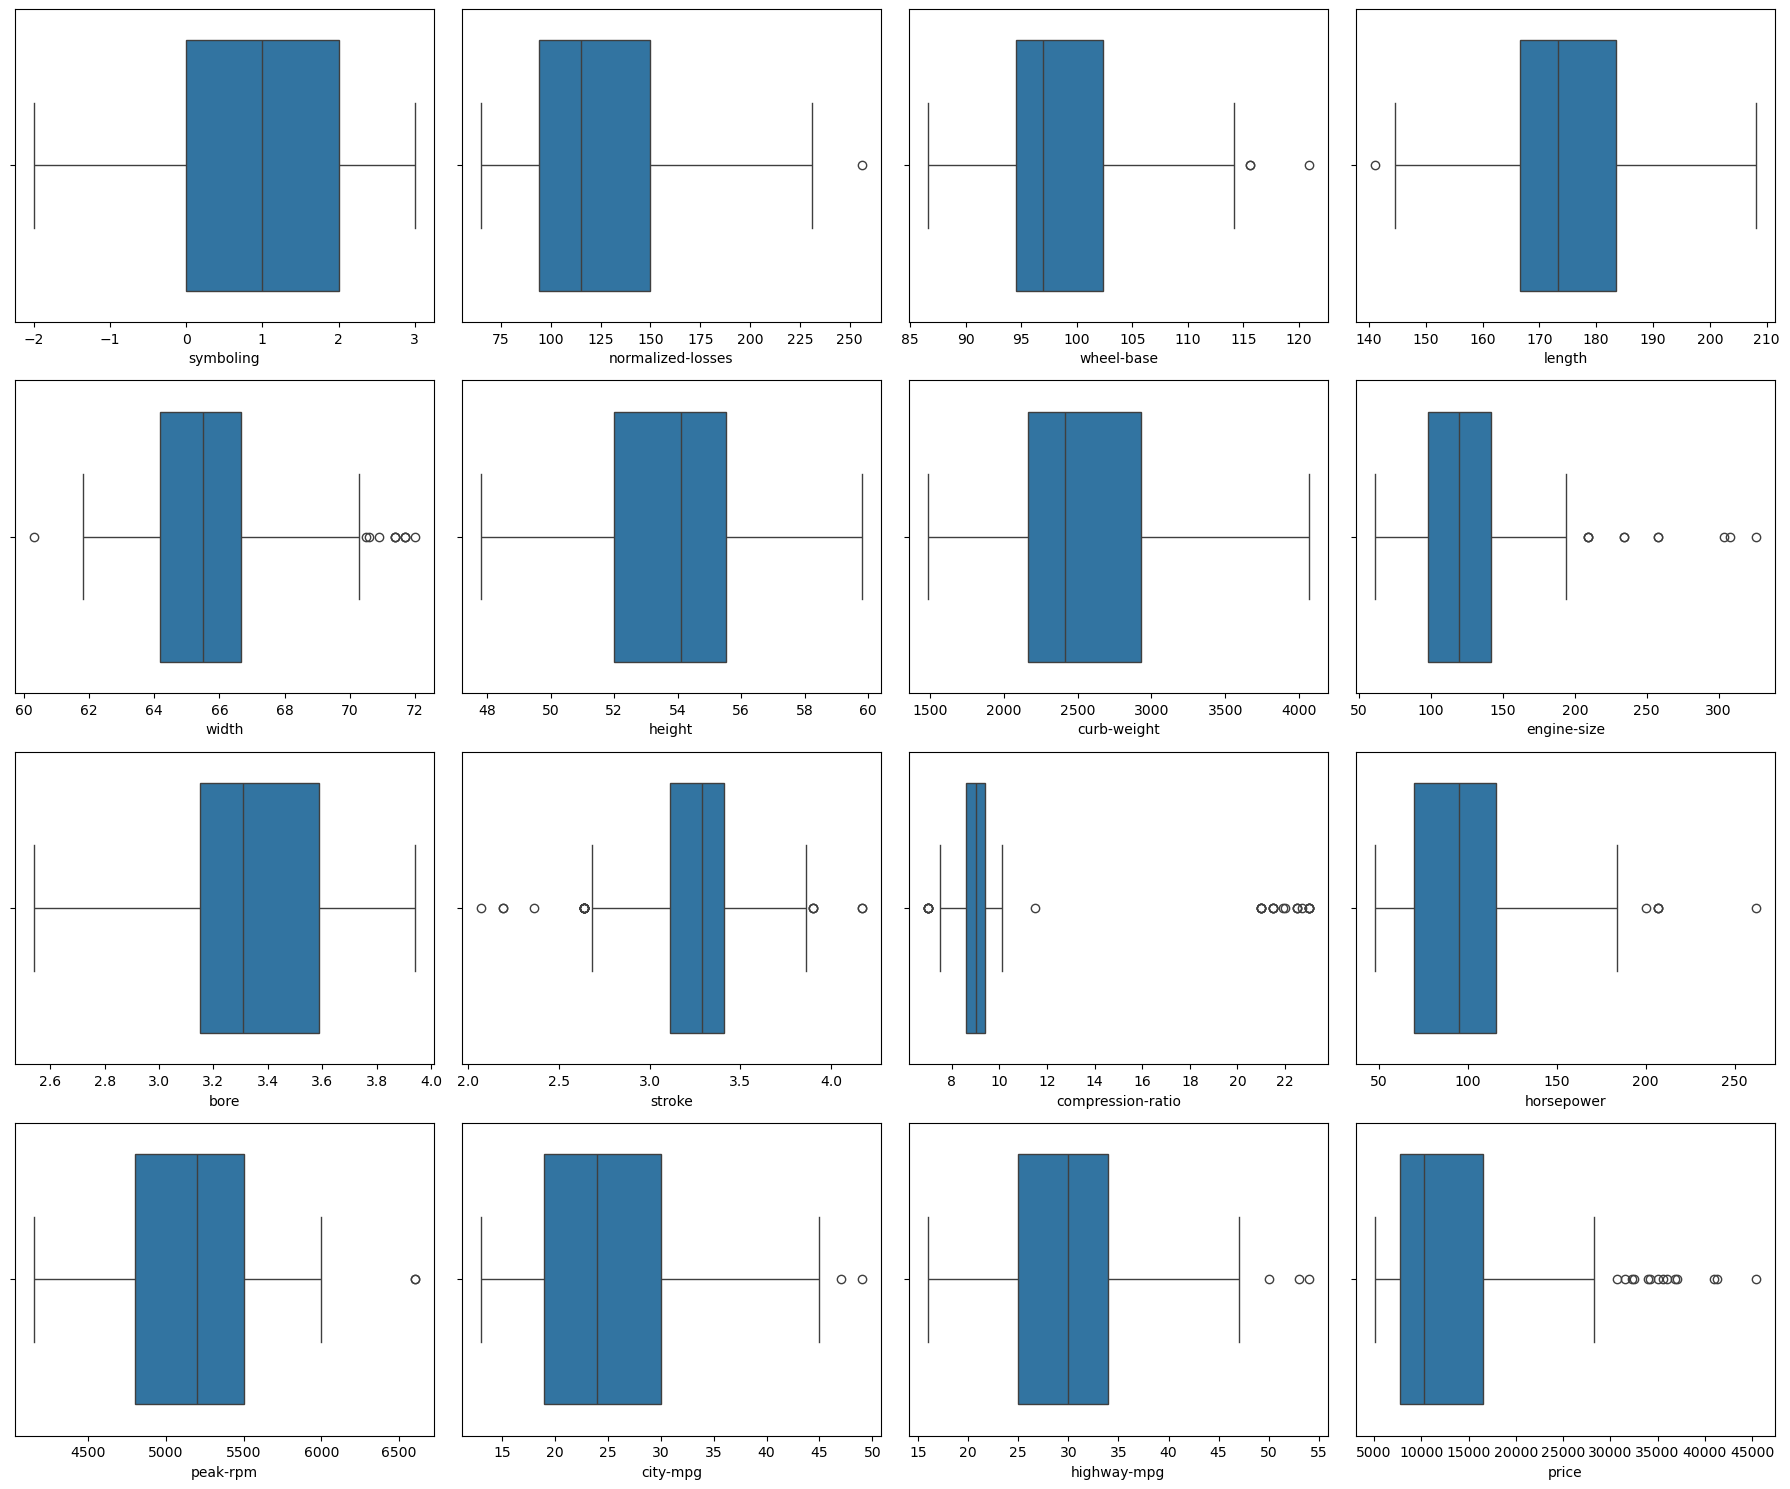

In [22]:
# Check for outlier - Using Boxplot to identify outlier.
plt.figure(figsize=(18,15))

for i, column in enumerate(num_data,1):
    plt.subplot(4,4,i)
    sns.boxplot(data=num_data, x=column)
    plt.xlabel(column)
    plt.tight_layout()

plt.show()

## Handling Outliers

In [23]:
# imputing with median 

outlier_column = ['normalized-losses','wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size',  'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg','highway-mpg']

In [24]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [25]:
# Function to handle outliers

def replace_outliers_with_median(df, outlier_column):

    for col in outlier_column:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3-Q1

            lower_bound = Q1-1.5*IQR
            upper_bound = Q3+1.5*IQR

            median_value = df[col].median()
            df[col]= df[col].mask((df[col]<lower_bound) & (df[col]>upper_bound), median_value)
        else:
            print(f"Warning: Column '{col}' not found in Dataframe.")
    return df

    

In [26]:
replace_outliers_with_median(df, outlier_column)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3.0,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0
1,1.0,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0
2,2.0,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0
3,2.0,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0
4,2.0,115.0,audi,gas,std,two,sedan,fwd,front,99.8,...,136.0,mpfi,3.19,3.40,8.5,110.0,5500.0,19.0,25.0,15250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1.0,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141.0,mpfi,3.78,3.15,9.5,114.0,5400.0,23.0,28.0,16845.0
196,-1.0,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141.0,mpfi,3.78,3.15,8.7,160.0,5300.0,19.0,25.0,19045.0
197,-1.0,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173.0,mpfi,3.58,2.87,8.8,134.0,5500.0,18.0,23.0,21485.0
198,-1.0,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145.0,idi,3.01,3.40,23.0,106.0,4800.0,26.0,27.0,22470.0


In [27]:
df.horsepower.describe()

count    200.000000
mean     103.275000
std       37.464749
min       48.000000
25%       70.000000
50%       95.000000
75%      116.000000
max      262.000000
Name: horsepower, dtype: float64

In [28]:
for col in outlier_column:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    
    print(col, df[(df[col] < low) | (df[col] > high)].shape[0])


normalized-losses 2
wheel-base 3
length 2
width 3
height 4
curb-weight 4
engine-size 3
stroke 3
compression-ratio 0
horsepower 2
peak-rpm 2
city-mpg 3
highway-mpg 4


* From above we can observe that result shows number of outliers which are below lower bound and above upper bound and these are replaced with median value for eg: horsepower had 2 outlier values, these get removed and replaced with the median value as per describe function.

## Feature Scaling

In [29]:
columns = num_data.drop('price',axis=1).columns
columns

Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'],
      dtype='object')

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[columns] = scaler.fit_transform(df[columns])

In [31]:
df1 = df.copy()  # new dataframe is used to store copy, now we work on df1 rather than df to keep original data without manipulation.

In [32]:
df1.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,1.742368,-0.178766,alfa-romero,gas,std,two,convertible,rwd,front,-1.701436,...,0.075578,mpfi,0.524067,-1.851995,-0.292224,0.206711,-0.248897,-0.654574,-0.544042,16500.0
1,0.136499,-0.178766,alfa-romero,gas,std,two,hatchback,rwd,front,-0.721882,...,0.605109,mpfi,-2.424744,0.668594,-0.292224,1.357337,-0.248897,-0.966276,-0.690882,16500.0
2,0.939433,1.347283,audi,gas,std,four,sedan,fwd,front,0.158057,...,-0.429882,mpfi,-0.521081,0.445251,-0.042481,-0.034117,0.796888,-0.187021,-0.103522,13950.0
3,0.939433,1.347283,audi,gas,std,four,sedan,4wd,front,0.091646,...,0.219996,mpfi,-0.521081,0.445251,-0.541967,0.313746,0.796888,-1.122127,-1.278241,17450.0
4,0.939433,-0.178766,audi,gas,std,two,sedan,fwd,front,0.158057,...,0.219996,mpfi,-0.521081,0.445251,-0.417096,0.179953,0.796888,-0.966276,-0.837722,15250.0


## Converting Categorical Data into numeric format for Machine learning purpose

In [33]:
# identify unique values and count of categorical data
for column in cat_data:
    print(column,df[column].unique())
    print(df[column].value_counts())
    print("------------------------")

make ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
volkswagen       12
subaru           12
peugot           11
volvo            11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
jaguar            3
chevrolet         3
isuzu             2
renault           2
alfa-romero       2
mercury           1
Name: count, dtype: int64
------------------------
fuel-type ['gas' 'diesel']
fuel-type
gas       180
diesel     20
Name: count, dtype: int64
------------------------
aspiration ['std' 'turbo']
aspiration
std      164
turbo     36
Name: count, dtype: int64
------------------------
num-of-doors ['two' 'four']
num-of-doors
four    

In [34]:
# Finding the unique values in car make column having count less than 10
value_counts = df1.make.value_counts()
unique_values = value_counts[value_counts<10].index.tolist()

In [35]:
# Replacing those unique_values with others
df1['make'] = df1.make.apply(lambda x: 'others' if x in unique_values else x)
df1.make.value_counts()

make
others        61
toyota        32
nissan        18
mazda         17
honda         13
mitsubishi    13
subaru        12
volkswagen    12
peugot        11
volvo         11
Name: count, dtype: int64

## One Hot encoding to other categorical variables

In [36]:
df2 = pd.get_dummies(cat_data, drop_first = True, dtype=int)

In [37]:
df3 = pd.concat([df1, df2], axis=1)
df3

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,1.742368,-0.178766,others,gas,std,two,convertible,rwd,front,-1.701436,...,0,0,0,0,0,0,0,1,0,0
1,0.136499,-0.178766,others,gas,std,two,hatchback,rwd,front,-0.721882,...,0,0,0,0,0,0,0,1,0,0
2,0.939433,1.347283,others,gas,std,four,sedan,fwd,front,0.158057,...,0,0,0,0,0,0,0,1,0,0
3,0.939433,1.347283,others,gas,std,four,sedan,4wd,front,0.091646,...,0,0,0,0,0,0,0,1,0,0
4,0.939433,-0.178766,others,gas,std,two,sedan,fwd,front,0.158057,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1.469370,-0.801643,volvo,gas,std,four,sedan,rwd,front,1.702100,...,0,0,0,0,0,0,0,1,0,0
196,-1.469370,-0.801643,volvo,gas,turbo,four,sedan,rwd,front,1.702100,...,0,0,0,0,0,0,0,1,0,0
197,-1.469370,-0.801643,volvo,gas,std,four,sedan,rwd,front,1.702100,...,0,0,0,0,0,0,0,1,0,0
198,-1.469370,-0.801643,volvo,diesel,turbo,four,sedan,rwd,front,1.702100,...,0,0,0,0,0,1,0,0,0,0


In [99]:
# Now drop categorical column as we encoded them into dummies
df3.drop(columns=cat_data.columns, axis=1,inplace=True)

## Correlation Heatmap

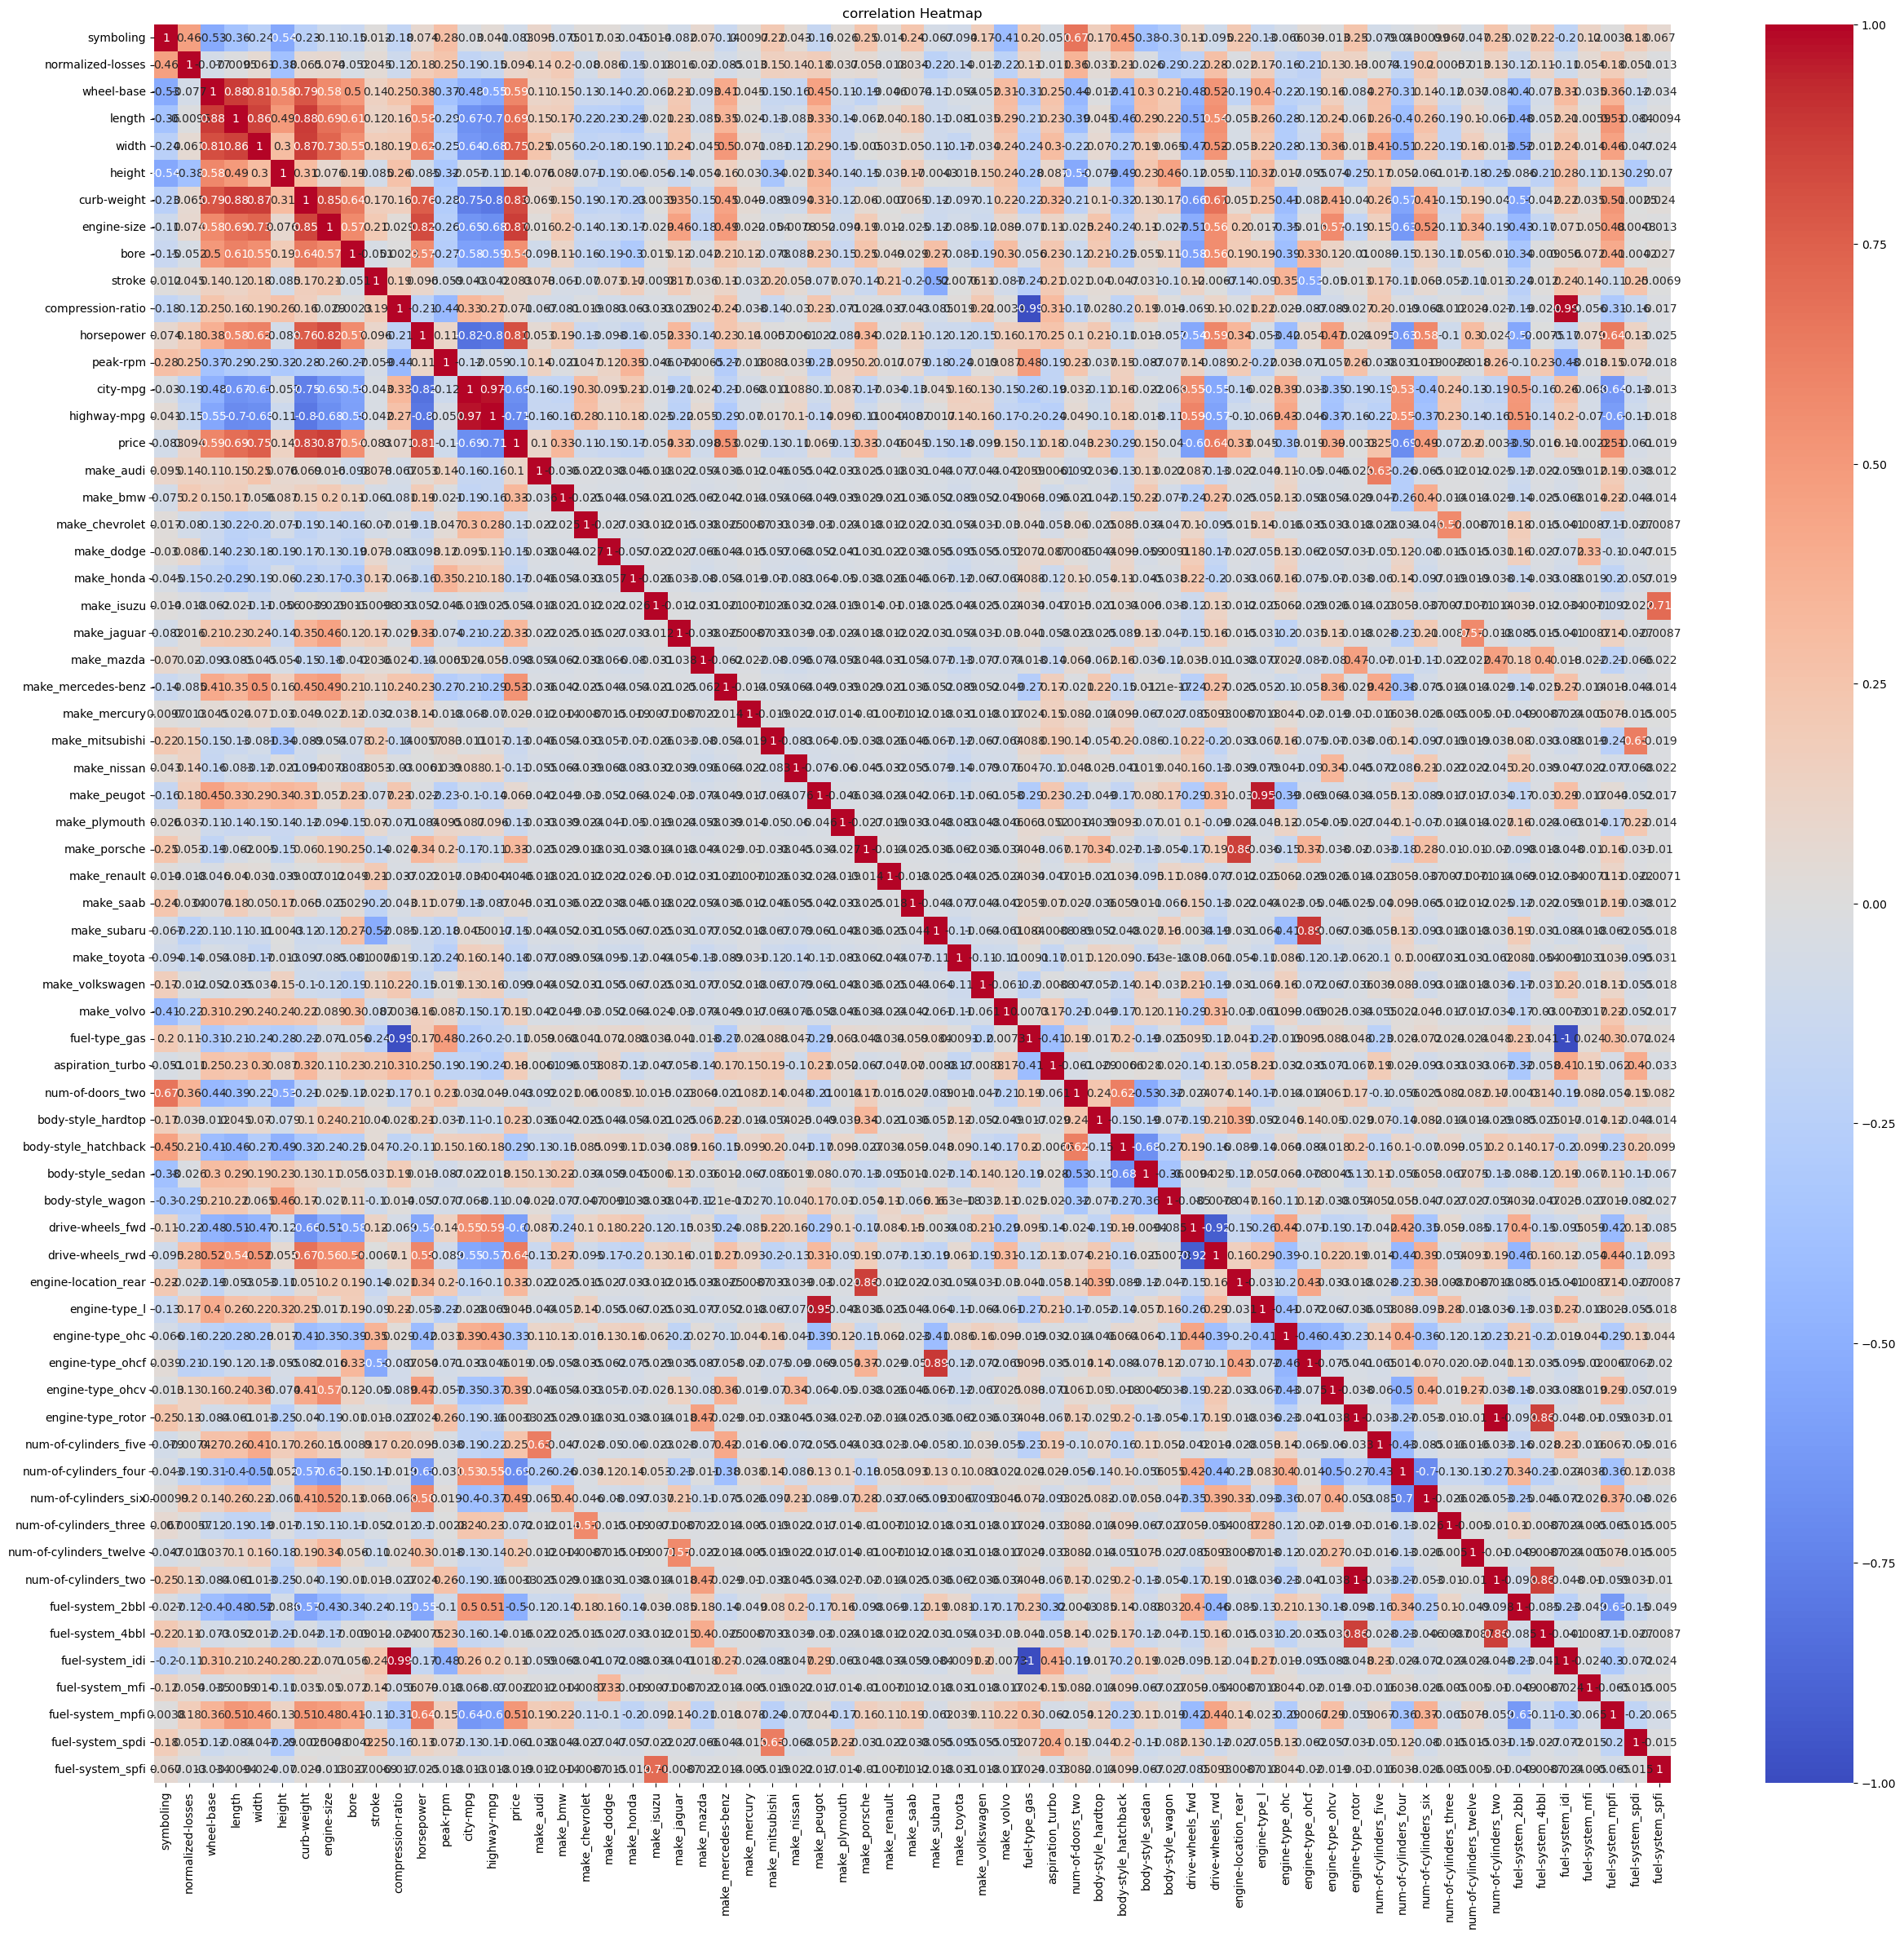

In [100]:
plt.figure(figsize=(30, 28))
sns.heatmap(df3.corr(), annot=True,cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()

In [101]:
df3.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
symboling,1.000000,0.462765,-0.529145,-0.364511,-0.237262,-0.542261,-0.234743,-0.112069,-0.148260,0.011596,...,0.066595,-0.047242,0.248910,-0.026852,0.215014,-0.195381,0.123513,0.003789,0.184559,0.066595
normalized-losses,0.462765,1.000000,-0.077168,-0.009513,0.061155,-0.377599,0.065385,0.073660,-0.051668,0.044772,...,0.000574,-0.012672,0.130181,-0.124969,0.112454,-0.106304,0.053560,0.183140,0.051334,-0.012672
wheel-base,-0.529145,-0.077168,1.000000,0.879005,0.814593,0.583789,0.787584,0.576779,0.502386,0.143529,...,-0.122965,0.037097,-0.084152,-0.401245,-0.072692,0.306706,-0.034696,0.359298,-0.121862,-0.033519
length,-0.364511,-0.009513,0.879005,1.000000,0.857271,0.492955,0.881058,0.685531,0.611417,0.120060,...,-0.190674,0.100563,-0.060640,-0.478216,-0.052382,0.210616,-0.005917,0.510386,-0.083918,-0.009370
width,-0.237262,0.061155,0.814593,0.857271,1.000000,0.300995,0.867720,0.731100,0.548589,0.182657,...,-0.189180,0.158900,-0.013485,-0.520552,-0.011648,0.243448,0.013585,0.456085,-0.046936,-0.023588
height,-0.542261,-0.377599,0.583789,0.492955,0.300995,1.000000,0.310660,0.076255,0.190367,-0.084595,...,-0.017310,-0.175335,-0.247190,-0.085648,-0.213529,0.281198,-0.105101,0.127971,-0.289978,-0.069985
curb-weight,-0.234743,0.065385,0.787584,0.881058,0.867720,0.310660,1.000000,0.849090,0.644914,0.168089,...,-0.146314,0.191068,-0.039893,-0.567621,-0.041518,0.221082,0.034985,0.510248,-0.002534,0.024433
engine-size,-0.112069,0.073660,0.576779,0.685531,0.731100,0.076255,0.849090,1.000000,0.574708,0.205467,...,-0.112373,0.339782,-0.186917,-0.434471,-0.168889,0.070925,0.049720,0.476765,0.004795,-0.013411
bore,-0.148260,-0.051668,0.502386,0.611417,0.548589,0.190367,0.644914,0.574708,1.000000,-0.051221,...,-0.111027,0.055672,-0.010451,-0.341455,-0.009028,0.055866,0.071548,0.412882,-0.004177,0.026566
stroke,0.011596,0.044772,0.143529,0.120060,0.182657,-0.084595,0.168089,0.205467,-0.051221,1.000000,...,-0.052122,-0.113190,0.013469,-0.241747,0.011635,0.239350,0.144652,-0.107992,0.250562,-0.006887


In [108]:
correlation_values = abs(df3.corr()['price'].drop('price')).sort_values(ascending=False)
(correlation_values)

engine-size                0.872337
curb-weight                0.834420
horsepower                 0.810551
width                      0.752795
highway-mpg                0.705115
num-of-cylinders_four      0.692552
length                     0.691044
city-mpg                   0.687186
drive-wheels_rwd           0.639982
drive-wheels_fwd           0.597893
wheel-base                 0.589147
bore                       0.543436
make_mercedes-benz         0.525046
fuel-system_mpfi           0.511018
fuel-system_2bbl           0.498285
num-of-cylinders_six       0.486329
engine-type_ohcv           0.394572
engine-type_ohc            0.334733
make_jaguar                0.332216
make_bmw                   0.331679
engine-location_rear       0.331098
make_porsche               0.327073
body-style_hatchback       0.293367
num-of-cylinders_five      0.254094
body-style_hardtop         0.231242
num-of-cylinders_twelve    0.203327
make_toyota                0.182321
aspiration_turbo           0

## Feature Selection
 * selecting features which have a high correlation with target price ( set threshold > 0.5)

In [109]:
threshold = 0.5
selected_features = correlation_values[correlation_values > threshold].index.tolist()

In [110]:
print("Selected Features :", selected_features)

Selected Features : ['engine-size', 'curb-weight', 'horsepower', 'width', 'highway-mpg', 'num-of-cylinders_four', 'length', 'city-mpg', 'drive-wheels_rwd', 'drive-wheels_fwd', 'wheel-base', 'bore', 'make_mercedes-benz', 'fuel-system_mpfi']


In [111]:
df4 = df3[['engine-size', 'curb-weight', 'horsepower', 'width', 'highway-mpg', 'num-of-cylinders_four','length', 'city-mpg',
           'drive-wheels_rwd', 'drive-wheels_fwd', 'wheel-base', 'bore', 'make_mercedes-benz', 'fuel-system_mpfi']]
df4.head()
df4 = df4.copy()

In [112]:
df4.head()

,engine-size,curb-weight,horsepower,width,highway-mpg,num-of-cylinders_four,length,city-mpg,drive-wheels_rwd,drive-wheels_fwd,wheel-base,bore,make_mercedes-benz,fuel-system_mpfi
0,0.075578,-0.014895,0.206711,-0.857154,-0.544042,1,-0.440719,-0.654574,1,0,-1.701436,0.524067,0,1
1,0.605109,0.516715,1.357337,-0.189737,-0.690882,0,-0.245855,-0.966276,1,0,-0.721882,-2.424744,0,1
2,-0.429882,-0.422785,-0.034117,0.143971,-0.103522,1,0.192591,-0.187021,0,1,0.158057,-0.521081,0,1
3,0.219996,0.518648,0.313746,0.239316,-1.278241,0,0.192591,-1.122127,0,0,0.091646,-0.521081,0,1
4,0.219996,-0.094153,0.179953,0.191644,-0.837722,0,0.249427,-0.966276,0,1,0.158057,-0.521081,0,1


In [113]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Creating a new dataframe with selected features.
X = df4[selected_features]

# Adding a constant column for statsmodel.
X = sm.add_constant(X)

# Caluculating VIF for each feature.
vif_data = pd.DataFrame()
vif_data["Features"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

# Dropping the constant column
vif_data = vif_data[vif_data['Features'] != 'const']

# Sort by VIF
print(vif_data.sort_values(by="VIF", ascending=False))

                 Features        VIF
5             highway-mpg  27.178110
8                city-mpg  26.369488
2             curb-weight  16.020907
7                  length  10.080291
3              horsepower   9.221062
10       drive-wheels_fwd   8.940797
9        drive-wheels_rwd   8.213219
1             engine-size   7.265517
11             wheel-base   7.258851
4                   width   6.282375
12                   bore   2.654644
6   num-of-cylinders_four   2.509740
14       fuel-system_mpfi   2.087183
13     make_mercedes-benz   1.877457


1. Remove Highly correlated features

   * Highway-mpg vs city-mpg have high multicollinearity because they depend one among each other. (VIF>10) have strong correlation among featutres (predictors). it is best to remove those which are (VIF>10) but here highway-mpg had strong collinearity with the target, so we keep that one and drop city-mpg.

    * Curb-weight, Engine size vs length, width, wheel base :
  
      if vehicle has max_weight obviously it is bigger in size in terms of (length, width, wheelbase) and for bigger vehicle it need bigger engine to make it's performance optimal so these features are correlated to each other. Among Length, Width and wheelbase, we can keep width and drop length & wheel_base. Among curb_weight & engine size (VIF 7.26) keep this one drop curb_weight.

2. Keeping Features Low VIF(<5)

    * Features like horsepower, width, bore, engine_size, make_mercedes_benz and fuel-system-mpfi, had low VIF, they are best predictors with minimal multicollinearity and high collinearity with target.

3. Adressing Multicollinearity in Categorical Features

   * drive-wheels_fwd vs. drive-wheels_rwd → These categories had moderate collinearity. Considered keeping one or combining them into a single feature to reduce redundancy
   

   

In [114]:
# Drop city-mpg since Highway-mpg most correlated with price
df4.drop(columns=['city-mpg'], inplace=True)

In [115]:
# Drop curb-weight it is correlated with engine_size & length
df4.drop(columns=['curb-weight'], inplace=True)

In [116]:
# Drop length among width and wheelbase because length > VIF causes model instability.
df4.drop(columns=['length'], inplace=True)

In [117]:
# Among FWD and RWD dr0p RWD and FWD has high corelation with target.
df4.drop(columns=['drive-wheels_rwd'], inplace=True) # Assuming we keep 'drive-wheels_fwd'

In [118]:
df4['price'] = df['price']

In [119]:
df4.head()

,engine-size,horsepower,width,highway-mpg,num-of-cylinders_four,drive-wheels_fwd,wheel-base,bore,make_mercedes-benz,fuel-system_mpfi,price
0,0.075578,0.206711,-0.857154,-0.544042,1,0,-1.701436,0.524067,0,1,16500.0
1,0.605109,1.357337,-0.189737,-0.690882,0,0,-0.721882,-2.424744,0,1,16500.0
2,-0.429882,-0.034117,0.143971,-0.103522,1,1,0.158057,-0.521081,0,1,13950.0
3,0.219996,0.313746,0.239316,-1.278241,0,0,0.091646,-0.521081,0,1,17450.0
4,0.219996,0.179953,0.191644,-0.837722,0,1,0.158057,-0.521081,0,1,15250.0


In [122]:
# Finding the best features for price prediction
best_features = pd.DataFrame(correlation_values).sort_values(by='price', ascending=False)[0:10]
best_features

,price
engine-size,0.872337
curb-weight,0.834420
horsepower,0.810551
width,0.752795
highway-mpg,0.705115
num-of-cylinders_four,0.692552
length,0.691044
city-mpg,0.687186
drive-wheels_rwd,0.639982
drive-wheels_fwd,0.597893


In [123]:
df4.to_csv("autoprice_model_data",index=False) # Saving File

In [126]:
data = pd.read_csv("autoprice_model_data")

In [127]:
data.head()

,engine-size,horsepower,width,highway-mpg,num-of-cylinders_four,drive-wheels_fwd,wheel-base,bore,make_mercedes-benz,fuel-system_mpfi,price
0,0.075578,0.206711,-0.857154,-0.544042,1,0,-1.701436,0.524067,0,1,16500.0
1,0.605109,1.357337,-0.189737,-0.690882,0,0,-0.721882,-2.424744,0,1,16500.0
2,-0.429882,-0.034117,0.143971,-0.103522,1,1,0.158057,-0.521081,0,1,13950.0
3,0.219996,0.313746,0.239316,-1.278241,0,0,0.091646,-0.521081,0,1,17450.0
4,0.219996,0.179953,0.191644,-0.837722,0,1,0.158057,-0.521081,0,1,15250.0


## Model Training

In [128]:
from sklearn.model_selection import train_test_split

In [129]:
x = data.drop("price", axis=1)
y = data.price

In [141]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Model Building (Linear Regression)
model_lr = LinearRegression()
model_lr.fit(x_train,y_train)


LinearRegression()

In [142]:
# evaluate model on test_data
y_pred_test_lr = model_lr.predict(x_test)

# evaluate model on train data
y_pred_train_lr = model_lr.predict(x_train)

In [144]:
# Model evaluation
test_acc_r2_lr = r2_score(y_test, y_pred_test_lr)
train_acc_r2_lr = r2_score(y_train, y_pred_train_lr)

print("Training R2 accuracy score using Linear regression :", train_acc_r2_lr)
print("Testing R2 accuracy score using Linear regression :", test_acc_r2_lr)
print("Testing adjusted R2 score :", (1-((1-test_acc_r2_lr)*(41-1))/(41-22-1)))
MSE_lr = mean_squared_error(y_test, y_pred_test_lr)
print("MSE score is :", MSE_lr)
print("MAE score is :", mean_absolute_error(y_test, y_pred_test_lr))
print("RMSE score is :", np.sqrt(MSE_lr))

Training R2 accuracy score using Linear regression : 0.83221983013317
Testing R2 accuracy score using Linear regression : 0.9018207624483595
Testing adjusted R2 score : 0.7818239165519101
MSE score is : 11000807.27892459
MAE score is : 2201.3630252667563
RMSE score is : 3316.7464899995884


In [145]:
# check for overfitting
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_lr, x_train, y_train, cv=5, scoring='r2')
print("cross_validation R2 scores :", cv_scores)
print("mean cross_validation R2 score :", cv_scores.mean())

cross_validation R2 scores : [0.72561008 0.51198093 0.85396175 0.78649582 0.7319575 ]
mean cross_validation R2 score : 0.7220012145307473


 * Mean cross validation R2-score (0.72) is significantly lower than the test R2-score(0.90). This suggesting that our model might be overfitting 

In [191]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Define alpha values to test
param_grid = {'alpha' : [0.01, 0.1, 1, 10, 500, 1000]}
ridge_cv = GridSearchCV( Ridge(), param_grid, cv=5, scoring='r2')
ridge_cv.fit(x_train, y_train)

print("Best Alpha for Ridge :", ridge_cv.best_params_['alpha'])
print("Best Ridge R2 score (CV) :", ridge_cv.best_score_)

# Train Ridge with best alpha
best_ridge = Ridge(alpha=ridge_cv.best_params_['alpha'])
best_ridge.fit(x_train, y_train)

# Evaluate on test set
y_pred_best_ridge = best_ridge.predict(x_test)
y_pred_train_best_ridge = best_ridge.predict(x_train)
best_ridge_test_r2 = r2_score(y_test, y_pred_best_ridge)
best_ridge_train_r2 = r2_score(y_train,y_pred_train_best_ridge)
print("Final Ridge Test R2 score  with Best Alpha:", best_ridge_test_r2)
print("Final Ridge Train R2 score  with Best Alpha:", best_ridge_train_r2)
print("Final Ridge MAE score is:", mean_absolute_error(y_test, y_pred_best_ridge))



Best Alpha for Ridge : 10
Best Ridge R2 score (CV) : 0.734819625894854
Final Ridge Test R2 score  with Best Alpha: 0.8750109302109076
Final Ridge Train R2 score  with Best Alpha: 0.8236974795533307
Final Ridge MAE score is: 2747.4702612224296


 * Final Ridge Test R2 score = 0.87, which is very closer to original linear regression model test R2 score = 0.90 but with better generalization.
 * Cross-validation R2 = 0.734, so Ridge regression still helps reduce overfitting slightly compared to LinarRegression
 * if ridge test R2 is slightly lower but CV ridge score is lightly higher (validating the scores closer) it means Ridge is stabilizing the model.

## DecisionTree Regressor 

In [148]:
from sklearn.tree import DecisionTreeRegressor
model_dt = DecisionTreeRegressor()
model_dt.fit(x_train, y_train)

DecisionTreeRegressor()

In [150]:
# evaluate model on test set
y_pred_test_dt = model_dt.predict(x_test)

# evaluate model on train set
y_pred_train_dt = model_dt.predict(x_train)

In [153]:
# Model evaluation

test_acc_r2_score = r2_score(y_test,y_pred_test_dt)
train_acc_r2_score =  r2_score(y_train,y_pred_train_dt)

print(" The test accuracy R2 score is : " ,test_acc_r2_score)
print(" The train accuracy R2 score is : " ,train_acc_r2_score)
print("Testing Adjusted R2 score is: ",(1-((1-test_acc_r2_score )*(41-1))/(41-22-1)))
MSE_dt = mean_squared_error(y_test,y_pred_test_dt)
print("MSE score is: ", MSE_dt)
print("RMSE score is: ", np.sqrt(MSE_dt))
print("MAE score is: ", mean_absolute_error(y_test,y_pred_test_dt))

 The test accuracy R2 score is :  0.9728024359322942
 The train accuracy R2 score is :  0.9866207686841955
Testing Adjusted R2 score is:  0.9395609687384315
MSE score is:  3047438.218367347
RMSE score is:  1745.6913296362982
MAE score is:  1271.7035714285714


## Hyper Parameter tuning for Decisiontree Regressor

In [174]:
# define parameters
param_grid = {
        'max_depth': [3,5,10,None],
        'min_samples_split' : [2,5,10],
        'min_samples_leaf' : [1,2,4]
}

# intialize model
model_dt = DecisionTreeRegressor(random_state = 42)

# perform GridSearchCv
grid_search = GridSearchCV(model_dt, param_grid, cv=5,scoring='r2', n_jobs=-1)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [176]:
# get the best parameters
best_params = grid_search.best_params_
print("Best parameters :", best_params)

Best parameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [179]:
# train with best parameters
best_dt = DecisionTreeRegressor(max_depth = 10,  min_samples_leaf = 1, min_samples_split = 5, random_state=42)
best_dt.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)

In [180]:
# Evaluate performance
y_pred_train = best_dt.predict(x_train)
y_pred_test = best_dt.predict(x_test)

print("Tuned Train R2 Score:", r2_score(y_train, y_pred_train))
print("Tuned Test R2 Score:", r2_score(y_test, y_pred_test))
MSE_tuned_dt = mean_squared_error(y_test,y_pred_test)
print("MSE score is: ", MSE_tuned_dt)
print("RMSE score is: ", np.sqrt(MSE_tuned_dt))
print("MAE score is: ", mean_absolute_error(y_test,y_pred_test))

Tuned Train R2 Score: 0.9748722522390851
Tuned Test R2 Score: 0.9057280325161676
MSE score is:  10563004.683645124
RMSE score is:  3250.0776427102664
MAE score is:  1764.3535714285713


 Even after Tuning model gets low test R2 score, MAE score, RMSE score, our model is going to   overfit.
 * When  tuned the model, hyperparameters reduced the tree size:

  1. max_depth became smaller

  2. min_samples_leaf increased

  3. min_samples_split increased


 * After Tuning of DecisionTree Model
 
 1. Test R2 dropped from 0.97 → 0.90

 2. RMSE doubled

 3. MAE increased

 4. Train R2 also dropped

This means:
* The tuning removed useful splits
* The tree became too small
* It cannot capture the dataset patterns anymore

 So keep the DecisionTree model has final model for our Project to consider best results.

In [182]:
# export and save the best Decisiontree model before tuning
import joblib
joblib.dump(model_dt, "decision_tree_final.joblib")


['decision_tree_final.joblib']

## Comparing the Actual_price vs Predicted_price of Model (car price)

In [189]:
import pandas as pd

# Predict on test data
Model = model_dt.fit(x_train, y_train)

y_pred = Model.predict(x_test)
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_test_dt
})

print(comparison.head(20))


    Actual Price  Predicted Price
0         8949.0           9549.0
1        36880.0          33900.0
2         5399.0           6479.0
3         8058.0           8238.0
4        12170.0          13680.0
5         7957.0           8257.5
6        40960.0          45400.0
7         9988.0          11073.0
8        15998.0          16558.0
9        36000.0          33900.0
10       31600.0          26900.0
11        9495.0           8249.0
12       11199.0          11826.5
13       12629.0          14679.0
14       13295.0          15250.0
15        7775.0           7995.0
16        8495.0          10420.0
17        7198.0           6938.0
18        8189.0           7744.0
19       35056.0          33900.0


 Plotting the Graph for Visualization of Actual vs Predicted in the form of Graph(line format) for Better Analysis.

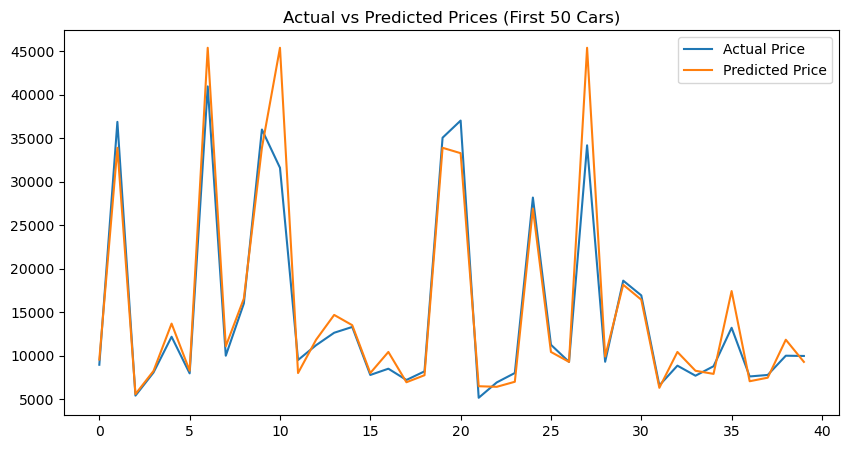

In [190]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual Price")
plt.plot(y_pred[:50], label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Prices (First 50 Cars)")
plt.show()


## Model Comparison Report

In [192]:
# Model performance dictionary
model_results = {
    "Model": [
        "Linear Regression", 
        "Ridge Regression", 
        "Decision Tree (Before Tuning)", 
        "Decision Tree (After Tuning)",
    ],
    
    "Train R2": [
        0.832,
        0.823,
        0.98,
        0.97
    ],

    "Test R2" : [
        0.901,
        0.875,
        0.972,
        0.905
    ],

    "MAE" : [
        2201.03,
        2747.45,
        1271.70,
        1764.35
    ]
}

# Convert to DataFrame
df_results = pd.DataFrame(model_results)

# Display the table
print(df_results)
    

                           Model  Train R2  Test R2      MAE
0              Linear Regression     0.832    0.901  2201.03
1               Ridge Regression     0.823    0.875  2747.45
2  Decision Tree (Before Tuning)     0.980    0.972  1271.70
3   Decision Tree (After Tuning)     0.970    0.905  1764.35


 * For better or generalised model Train_score > Test_Score and Test_Score should be nearer to Train_score and MAE should be less and it is gradually decreased from LR Model to DT Model. Our model best fits for all criteria and satisfied with results as Best model.
 * XG_Boost slightly improves test & train score and may reduce MAE score but DecisionTree model well fitted without any tuning, since we have best score there is no need to go with XG_Boost.

## Model Comparison with Visualization

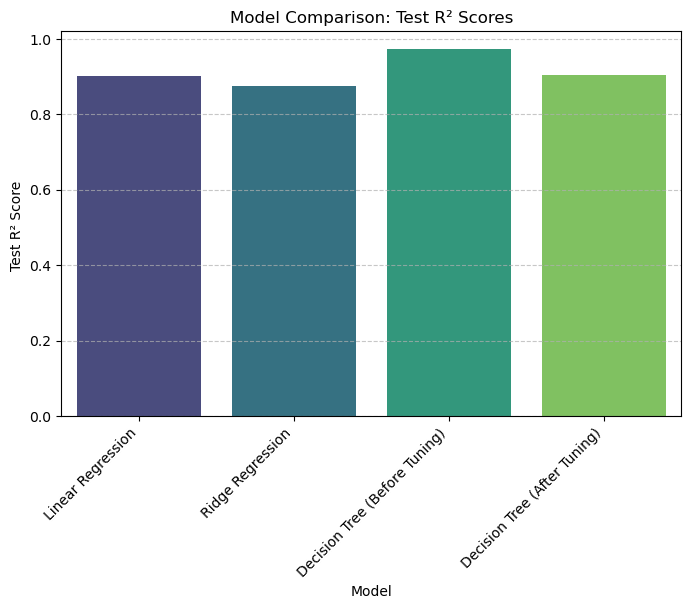

In [196]:
# Set the figure size
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test R2', hue='Model', data=model_results, dodge=False, legend=False, palette='viridis')

# Labels and Title
plt.ylabel('Test R² Score ')
plt.xlabel('Model')
plt.title('Model Comparison: Test R² Scores')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Grid for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 * Best Model : DecisionTree (Before Tuning).

    Based on the Test R2 Scores from bar plot, the best model is the optimized DecisionTree, it has the highest R2 score = 97%.

 * Highest Generalization performance :

  The optimized Decision Tree had test R2 score (97%), meaning it explains 97% variance of the test data. This indicates it makes most accurate predictions on the Unseen data.

 * Extreme Overfitting Control :

   The Train R2(~98%) is high but still reasonable, meaning model learned very well from the training data. Test R2 score is very closer considers as best model earlier Ridge Regression had Train_score(82%)  &  Test_score(87%) means neither learns nor predicts well slightly get underfit, This get overcomes in Decision Tree Model.

 * Feature Selection : Test R2 score indicates that best features are selected to get better results even for Decision Tree or else we further move for RandomForest and XG_Boost for better scores and Model stability.

## Conclusion
  1. Key insights from Data Analysis by visualization
     * The dataset was explored to identify important variables influencing car prices, such as engine size, horsepower, fuel type, and body style.
     * Correlation analysis revealed that engine size, horsepower, and curb weight had the highest impact on car prices, while categorical features like fuel type and drive wheels also played a role.
     * Outliers and missing values were identified and handled to ensure data quality.

  2. Predictive Model Evaluation:
     * Multiple Machine Learning Models are applied to predict car prices and their performances evaluated based on Train R2, Test R2, MAE Scores.

  3. Best Model Selection :
     * The Simple DecisionTree model emerged as the best choice for production because:
        * It achieved highest Test R2 score (97%), indicating strong Generalisation in the model performance.
        * It avoid underfitting as compared to Ridge Regression  and avoids overfitting as compared to Linear regression having high train_score & less test_score
        * It performed better than LinearRegression and RidgeRegression in predicting car prices.
     

## Challenges faced and Solutions Implemented
   * Creating Missed Column Names : Assigned appropriate names to features and target due to missing column names in dataset.
   
   * Converting categorical into numeric data : Make, fuel-type, aspiration,DRIVE-Wheel, Engine-type etc all columns converted into numeric format specially 'make' converts by label encoding and remaining columns converts by One-Hot encoder.
   
   * Scaling Numerical data : Used StandaradScaler (0 to 1) range to bring all the features into same scale for better model performance.
   
   * Impute Missing Values : Impute Missing values by median for num_data and mode for cat_data.
   
   * Handling Outlier : By simple IQR method to remove outliers as it is not normal distribution and replace those with median values. so that model performance could not affected.
   
   * Correlation : It is a very important factor determining model building to select best features, I used VIF to find collinearity among predictors & target and multicollinearity among predictors, Kept a Threshold VIF < 50% to avoid multicollinearity and pick columns have high correlation above 80%. This Feature Selection plays a vital rolre in both Model Building & performance.
   
   * Grouping Rare Categories in Make column : The model of cars which have less than 10 pins convert into 'others' and Combined remaining to reduce excessive dummy variables.
   
   *  Model Comparison and Selection : Implement Cross-validation scores and Hyper-parameter tuning to perform model well on Unseen data and it helps to generalize model for better performance.
   
   *  Ridge Regression : Improves scores helps in generalizing model by bringing test and train R2 scores nearer and reduce model redundancy and improves stability.
   
   *  Linear Regression Overfitting : Even after using best CV scores and HyperParameter tuning model gets overfitted but shows minimal improvement.

  Overall this project helps to optimized learning from basic analysis to Evaluation of model covering all aspects gives depth knowledge about Regression Problems.

## Bussiness Impact and Recommendations:

The model will help management understand price variations based on features, allowing strategic decisions in design, marketing, and pricing strategies.

   * Optimize Car Design : Mainly Adjust engine-size, Horsepower, Size of car, Mileage of the car, fuel-type & engine-type these features are mainly contributing for optimized price of the car, so that adjust features to target different price Segments.
   
   * Improve pricing strategy : Accurately price new car models based on feature importance.
   
   * Enhance market competativiness : Understands Trends and Preferences alligned with the customer demand and understand market, type of customers, per capita income to produce car type and fix optimal price including required features based on customer demand & satisfication.

## Best Model : DecisionTree Regressor algorithm
## Best SCore : Train R2 Score : 98% , Test R2 Score : 97%